# 04a — Choosing & Validating K (doc 10)

**Phase 4, part A.** Decide *how many* segments and prove they are real, before we ever name
one. Three steps:

- **4a** — the **one-timer split** decision: do we cluster everyone, or split off the
  single-purchase customers (degenerate: Recency = Tenure) and cluster the richer repeat-buyer
  space? (doc 17, Decision 3 — "lean ii".)
- **4b** — the **K-selection panel**: silhouette · gap statistic · elbow · CH · DB over K = 2–8.
- **4c** — **stability**: GMM BIC, bootstrap Jaccard, consensus matrix → pick K by triangulation.

Honest framing (doc 10): RFM behaviour is a **continuum**, so there may be no single "true" K —
we choose a *useful*, statistically supported, stable number. Every metric below is produced as
a comparison artifact (the project's observability rule). All logic lives in `src/clustering.py`.

In [1]:
import sys
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import clustering, utils

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
PHASE = "04a_choosing_k"
K_RANGE = range(2, 9)          # a sane business range — nobody runs 12 playbooks (doc 10)

In [2]:
# The scaled clustering matrix (log1p + RobustScaler on R/F/M/Tenure) and the RAW core features
# (we need raw Frequency to identify one-time buyers).
X = pd.read_parquet(utils.DATA_PROCESSED / "clustering_matrix.parquet")
core = pd.read_parquet(utils.DATA_PROCESSED / "core_features.parquet")
print("clustering matrix:", X.shape, "| features:", list(X.columns))
X.describe().round(2)

clustering matrix: (5852, 4) | features: ['Recency', 'Frequency', 'Monetary', 'Tenure']


,Recency,Frequency,Monetary,Tenure
count,"5,852.000","5,852.000","5,852.000","5,852.000"
mean,0.300,0.120,0.020,-0.160
std,0.590,0.580,0.730,0.630
min,-0.270,-0.500,-2.850,-1.490
25%,-0.200,-0.500,-0.490,-0.610
50%,0.000,0.000,-0.000,0.000
75%,0.800,0.500,0.510,0.390
max,1.820,3.270,3.460,0.590


## 4a — The one-timer split decision

One-time buyers bought on exactly one invoice, so for them **first == last purchase →
Recency == Tenure** and **AvgBasket == Monetary**: they collapse onto a line in feature space
(doc 17 degeneracy). They are ~28% of customers (doc 02 / EDA), a core CRM question in their own
right ("convert one-timers"), so we do **not** drop them. The question is only whether to *cluster*
them with everyone else (they can swamp a whole cluster) or **split them off** and cluster the
repeat-buyer space, treating one-timers as their own named segment later.

one-time buyers: 1,618 (27.6%)
repeat buyers  : 4,234 (72.4%)


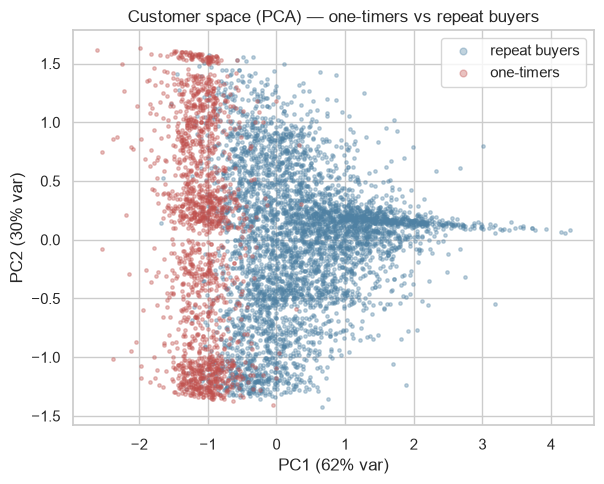

In [3]:
onetimer = core["Frequency"] == 1
repeat_ids = core.index[~onetimer]
print(f"one-time buyers: {onetimer.sum():,} ({onetimer.mean():.1%})")
print(f"repeat buyers  : {(~onetimer).sum():,} ({(~onetimer).mean():.1%})")

# PCA view of the FULL matrix, coloured by one-timer flag — show the degeneracy visually.
pcs = clustering.pca_2d(X)
ev = pcs.attrs["explained"]
fig, ax = plt.subplots(figsize=(6.2, 5))
for flag, name, c in [(False, "repeat buyers", "#4f81a3"), (True, "one-timers", "#c0504d")]:
    m = (onetimer.values == flag)
    ax.scatter(pcs.loc[m, "PC1"], pcs.loc[m, "PC2"], s=6, alpha=0.35, label=name, color=c)
ax.set_xlabel(f"PC1 ({ev[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({ev[1]:.0%} var)")
ax.set_title("Customer space (PCA) — one-timers vs repeat buyers")
ax.legend(markerscale=2)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "onetimer_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

**Evidence — read this one carefully (there is a trap).** We compare the silhouette of clustering
the full population vs the repeat-buyers-only matrix across K. The trap: one-timers are a
*degenerate, tightly-collapsed line* in feature space, so a full-population clustering can score a
**higher** silhouette simply by carving them off as one easy, cohesive blob — re-discovering a
group we already know deterministically (`Frequency == 1`). So a higher full-population silhouette
is evidence of that degeneracy *dominating* the partition, **not** of richer structure.

   full population  repeat buyers only
k                                     
2            0.368               0.348
3            0.402               0.367
4            0.350               0.336
5            0.326               0.305
6            0.305               0.305
7            0.312               0.298
8            0.314               0.281


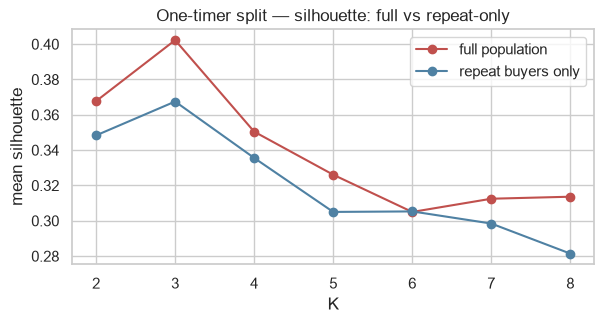

In [4]:
X_repeat = X.loc[repeat_ids]
sil_full = clustering.sweep_k(X, K_RANGE, method="kmeans")["silhouette"]
sil_repeat = clustering.sweep_k(X_repeat, K_RANGE, method="kmeans")["silhouette"]
compare = pd.DataFrame({"full population": sil_full, "repeat buyers only": sil_repeat})
print(compare.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.2, 3.4))
compare.plot(marker="o", ax=ax, color=["#c0504d", "#4f81a3"])
ax.set_xlabel("K")
ax.set_ylabel("mean silhouette")
ax.set_title("One-timer split — silhouette: full vs repeat-only")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "onetimer_silhouette.png"), dpi=150, bbox_inches="tight")
plt.show()

**Decision — split off (ii).** As predicted by the trap above, the full population scores a
*higher* silhouette at every K (K=3: **0.40 vs 0.37**) — precisely because its dominant split is
"one-timers vs everyone", a degenerate blob we can label deterministically. Clustering the full
population would spend cluster budget re-finding that known group; **splitting it off lets the
remaining clusters describe repeat-buyer structure**, where the marketing decisions live (doc 17
ii). So we cluster the repeat buyers and re-introduce one-timers as their own named segment in
profiling. Main clustering matrix `X_main = X_repeat`.

In [5]:
X_main = X_repeat
print(f"main clustering matrix (repeat buyers): {X_main.shape}")

main clustering matrix (repeat buyers): (4234, 4)


## 4b — The K-selection panel (doc 10)

Lead with **silhouette** + **gap statistic**; corroborate with **elbow (Kneedle)** + **CH/DB**.
Each index is biased differently (silhouette/CH/DB favour spheres; gap depends on the null), so
*agreement* is robust and *disagreement is itself a finding* (usually gradient structure).

In [6]:
panel = clustering.sweep_k(X_main, K_RANGE, method="kmeans")
elbow_k = clustering.knee_point(panel.index, panel["inertia"])
# Gap is run from K=1 (not 2): the gap statistic is UNIQUELY able to return K=1 = "no real
# clusters" (doc 10). Excluding K=1 would suppress that verdict and force a misleading high-K fallback.
gap = clustering.gap_statistic(X_main, range(1, 9), n_refs=10, reference="pca")
gap_k = clustering.gap_choice(gap)
sil_k = int(panel["silhouette"].idxmax())
ch_k = int(panel["calinski_harabasz"].idxmax())
db_k = int(panel["davies_bouldin"].idxmin())

print(panel.round(3).to_string())
print(f"\nvotes -> silhouette K={sil_k} | gap K={gap_k} | elbow K={elbow_k} | CH K={ch_k} | DB K={db_k}")

    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2 3,092.838       0.348          2,747.811           1.066
3 2,132.740       0.367          2,944.271           1.008
4 1,665.860       0.336          2,907.536           0.969
5 1,433.779       0.305          2,704.162           1.067
6 1,289.688       0.305          2,498.941           1.017
7 1,166.176       0.298          2,377.081           1.055
8 1,052.285       0.281          2,322.839           1.070

votes -> silhouette K=3 | gap K=1 | elbow K=4 | CH K=3 | DB K=4


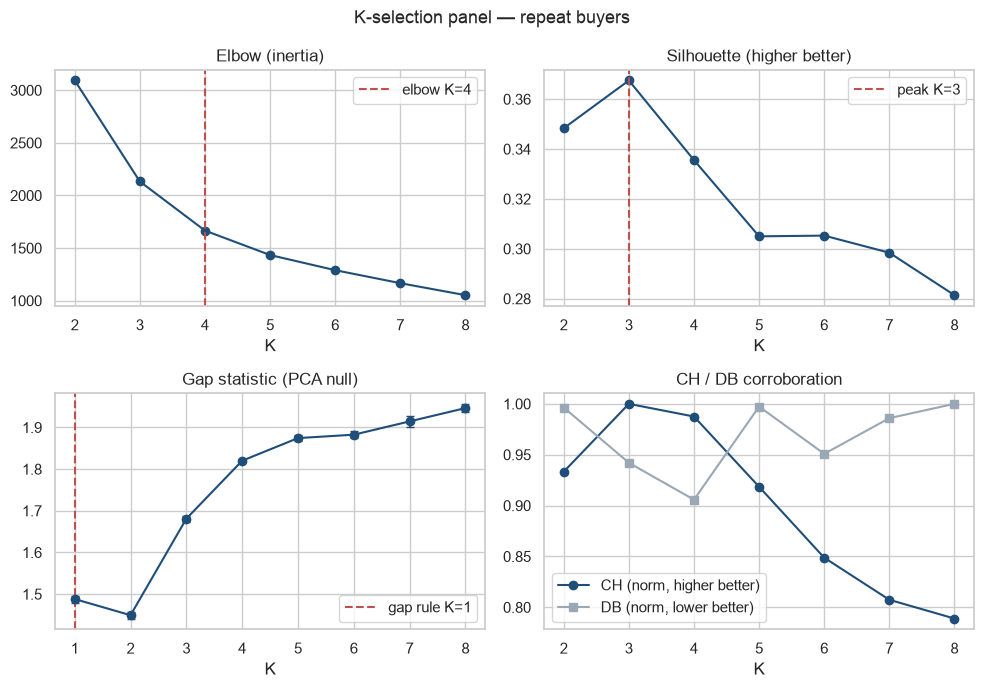

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].plot(panel.index, panel["inertia"], marker="o", color="#1f4e79")
axes[0, 0].axvline(elbow_k, color="#c0504d", ls="--", label=f"elbow K={elbow_k}")
axes[0, 0].set_title("Elbow (inertia)"); axes[0, 0].legend()
axes[0, 1].plot(panel.index, panel["silhouette"], marker="o", color="#1f4e79")
axes[0, 1].axvline(sil_k, color="#c0504d", ls="--", label=f"peak K={sil_k}")
axes[0, 1].set_title("Silhouette (higher better)"); axes[0, 1].legend()
axes[1, 0].errorbar(gap.index, gap["gap"], yerr=gap["s_k"], marker="o", color="#1f4e79", capsize=3)
axes[1, 0].axvline(gap_k, color="#c0504d", ls="--", label=f"gap rule K={gap_k}")
axes[1, 0].set_title("Gap statistic (PCA null)"); axes[1, 0].legend()
axes[1, 1].plot(panel.index, panel["calinski_harabasz"] / panel["calinski_harabasz"].max(),
                marker="o", label="CH (norm, higher better)", color="#1f4e79")
axes[1, 1].plot(panel.index, panel["davies_bouldin"] / panel["davies_bouldin"].max(),
                marker="s", label="DB (norm, lower better)", color="#9aa7b4")
axes[1, 1].set_title("CH / DB corroboration"); axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xlabel("K")
fig.suptitle("K-selection panel — repeat buyers", fontsize=13)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "k_selection_panel.png"), dpi=150, bbox_inches="tight")
plt.show()

**Reading the panel.** The robust, interpretable indices converge *low*: **silhouette peaks at
K=3** and **CH peaks at K=3**, with **elbow and DB at K=4** — a 3–4 candidate band, exactly where
RFM segmentation usually settles (doc 10). The **gap statistic selects K=1** — its built-in "no
real clusters" verdict (the gap never beats K=1 once the next K's noise is subtracted; equivalently
the gap just rises monotonically with no interior optimum). Either reading is the same finding: the
data is a **continuum** with no clean gaps (doc 10). We carry K ∈ {3, 4} forward and let
stability break the tie.

## 4c — Stability & a different-family vote (doc 10/11)

Internal indices say "how many blobs"; stability says "do they reproduce". And **GMM BIC** votes
on K from a different family of evidence than silhouette/gap.

   spherical       diag       tied       full
k                                            
2 23,871.000 20,273.000 19,559.000 14,809.000
3 21,367.000 16,966.000 15,787.000 12,440.000
4 19,302.000 15,221.000 15,254.000 10,751.000
5 18,336.000 14,401.000 14,981.000 10,490.000
6 17,601.000 12,664.000 14,326.000  9,561.000
7 17,236.000  4,763.000 14,216.000  2,157.000
8 16,444.000   -209.000 13,763.000  1,910.000

GMM BIC best: K=8, covariance=diag


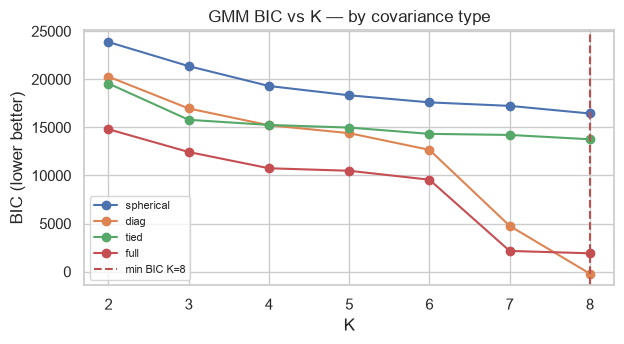

In [8]:
# GMM BIC across covariance types — lower is better; a K vote from the likelihood world.
bic = clustering.gmm_bic(X_main, K_RANGE, covariance_types=("spherical", "diag", "tied", "full"))
bic_k = int(bic.min(axis=1).idxmin())
best_cov = bic.loc[bic_k].idxmin()
print(bic.round(0).to_string())
print(f"\nGMM BIC best: K={bic_k}, covariance={best_cov}")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for cov in bic.columns:
    ax.plot(bic.index, bic[cov], marker="o", label=cov)
ax.axvline(bic_k, color="#c0504d", ls="--", label=f"min BIC K={bic_k}")
ax.set_xlabel("K"); ax.set_ylabel("BIC (lower better)")
ax.set_title("GMM BIC vs K — by covariance type")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "gmm_bic.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Bootstrap Jaccard stability at the CANDIDATE K's the indices flagged (every segment must survive).
candidates = sorted({sil_k, gap_k, bic_k, elbow_k})
candidates = [k for k in candidates if k >= 2]
print("candidate K's to stress-test:", candidates)
stab = {k: clustering.bootstrap_stability(X_main, k, method="kmeans", n_boot=100, frac=0.8)
        for k in candidates}
stab_summary = pd.DataFrame({
    "min_jaccard": {k: s.min() for k, s in stab.items()},
    "mean_jaccard": {k: s.mean() for k, s in stab.items()},
    "n_dissolving (<0.6)": {k: int((s < 0.6).sum()) for k, s in stab.items()},
})
stab_summary.index.name = "K"
print(stab_summary.round(3).to_string())

candidate K's to stress-test: [3, 4, 8]


   min_jaccard  mean_jaccard  n_dissolving (<0.6)
K                                                
3        0.787         0.790                    0
4        0.773         0.783                    0
8        0.735         0.760                    0


**GMM BIC — discount it here.** BIC falls monotonically and the `diag` covariance even goes
**negative at K=7–8** (BIC ≈ −209) — the tell-tale GMM **singularity / spurious-component** failure
mode (a component collapsing onto a handful of points, doc 11). So GMM's "K=8" is an overfitting
artifact, not evidence of eight real types; like the gap curve, it is the continuum showing through.
We do not let it override the silhouette / CH / stability signal.

**Triangulated decision.** Pick the K that the indices support AND that is stable (no cluster
dissolving < 0.6), breaking ties toward the smaller, more interpretable K (doc 10 Occam). The
chosen K is recorded below; disagreement among indices is reported, not hidden.

In [10]:
# Prefer a stable candidate (no dissolving cluster); among those, the one with the highest mean
# Jaccard, tie-broken to the smaller K. Fall back to the gap-rule K if none is clean.
stable = stab_summary[stab_summary["n_dissolving (<0.6)"] == 0]
if len(stable):
    CHOSEN_K = int(stable.sort_values(["mean_jaccard"], ascending=False).index[0])
else:
    CHOSEN_K = gap_k
print(f"CHOSEN_K = {CHOSEN_K}")

CHOSEN_K = 3


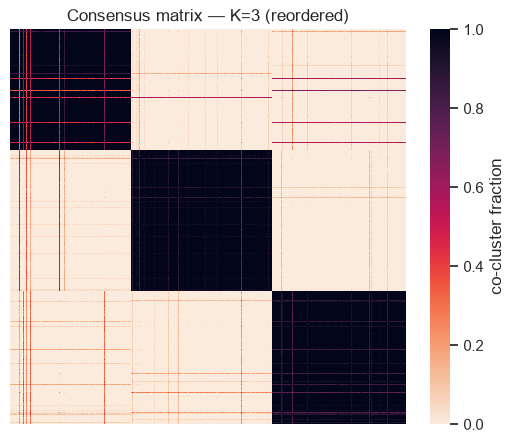

In [11]:
# Consensus matrix at the chosen K (on a subsample for speed/memory — doc 10) — crisp blocks = stable.
rng = np.random.default_rng(utils.RANDOM_SEED)
sub = rng.choice(len(X_main), size=min(1200, len(X_main)), replace=False)
X_sub = X_main.iloc[sub]
cons = clustering.consensus_matrix(X_sub, CHOSEN_K, method="kmeans", n_runs=40, frac=0.8)
order = np.argsort(clustering.labels_of(clustering.fit_kmeans(X_sub, CHOSEN_K), X_sub))
fig, ax = plt.subplots(figsize=(5.4, 4.6))
sns.heatmap(cons[np.ix_(order, order)], cmap="rocket_r", vmin=0, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax, cbar_kws={"label": "co-cluster fraction"})
ax.set_title(f"Consensus matrix — K={CHOSEN_K} (reordered)")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "consensus.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save the Phase-4a decision for 04b

04b (method comparison) needs: which customers are in the main clustering (repeat buyers), the
one-timer mask, and the chosen K.

In [12]:
proc = utils.DATA_PROCESSED
X_main.to_parquet(proc / "clustering_matrix_main.parquet")
onetimer.rename("is_onetimer").to_frame().to_parquet(proc / "onetimer_mask.parquet")
decision = {
    "chosen_k": CHOSEN_K,
    "approach": "split_off_onetimers",
    "n_onetimers": int(onetimer.sum()),
    "n_repeat": int((~onetimer).sum()),
    "votes": {"silhouette": sil_k, "gap": gap_k, "gmm_bic": bic_k, "elbow": elbow_k,
              "ch": ch_k, "db": db_k},
}
with open(proc / "cluster_choice.json", "w") as f:
    json.dump(decision, f, indent=2)
print("saved: clustering_matrix_main, onetimer_mask, cluster_choice.json")
print(json.dumps(decision, indent=2))

saved: clustering_matrix_main, onetimer_mask, cluster_choice.json
{
  "chosen_k": 3,
  "approach": "split_off_onetimers",
  "n_onetimers": 1618,
  "n_repeat": 4234,
  "votes": {
    "silhouette": 3,
    "gap": 1,
    "gmm_bic": 8,
    "elbow": 4,
    "ch": 3,
    "db": 4
  }
}


---
**Result:** one-timers split off (clustered separately as their own segment). **K = 3** chosen by
triangulation — silhouette + CH peak at 3, it is the most stable (mean Jaccard 0.79, nothing
dissolving), with **K = 4 a close, defensible runner-up** (elbow + DB, mean Jaccard 0.78). The two
"principled" indices land at opposite extremes — **gap → K=1** (its "no clusters" verdict) and
**BIC → K=8** (a GMM singularity) — and both extremes signal the same thing: no crisp K, a
**continuum**. That is doc 10's honest "behaviour is a gradient, choose a *useful* K" framing. **Next:**
`04b_method_comparison` — fit K-Means / GMM / Ward at K=3, the 3×3 ARI agreement, dendrogram, and
PCA label overlays (doc 11).